In [57]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [58]:
class PlannerState(MessagesState):
    next_agent : str =""
    res_data : str =""
    code_data : str =""
    revi_data : str =""
    fin_rep_data : str =""
    curr_task : str =""
    task_comp : bool = False
    coder_retry_count: int = 0

In [59]:
#importing our llm via GroqAPI

from dotenv import load_dotenv
load_dotenv()


True

In [60]:
import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
llm = init_chat_model("groq:openai/gpt-oss-20b")

In [61]:
os.environ["LANGSMITH_TRACING"]="true"

In [62]:
# define the chain ie the core which will generate the agent to go to next.
from langchain_core.prompts import ChatPromptTemplate
def superchain():
    sys_prompt = ChatPromptTemplate([("system", """You are a routing agent for a chain with exactly 4 agents: research, coder, reviewer, writer.

Inputs:
- has_res_data: {has_res_data}
- has_code_data: {has_code_data}
- has_revi_data: {has_revi_data}
- has_rep: {has_rep}
- task: {task}
- task_comp: {task_comp}

Rules:
- If {task_comp} is true, output only:
done
- Otherwise, choose exactly one next agent name based on the current task and the available data:
research
coder
reviewer
writer

Output rules:
- Output only one word.
- The output must be exactly one of:
done
research
code
review
write
- Do not output any extra text, punctuation, explanation, quotes, or formatting.
- Do not output multiple lines.
- Do not output JSON.

Decision logic:
- If the task is complete, respond with 'DONE'.
- Based on the current state and conversation, decide which agent should work next.
- Use has_res_data, has_code_data, and has_revi_data to determine whether the task has enough information to move forward.
- Select the most appropriate next agent for the current task state. """ ),("human","{task}")])

    return sys_prompt | llm

In [ ]:
#define all agent def one by one 
#1.planner agent.

def Planner_agent(state: PlannerState):

    has_res_data = bool(state.get("res_data",""))
    has_code_data = bool(state.get("code_data",""))
    has_revi_data =  bool(state.get("revi_data",""))
    has_rep = bool(state.get("fin_rep_data",""))
    coder_retry_count = state.get("coder_retry_count", 0)
    call = superchain()
    chainmess = call.invoke({
        "task": state["messages"][-1].content,
        "has_res_data" : has_res_data,
        "has_code_data" : has_code_data,
        "has_revi_data" : has_revi_data,
        "has_rep" : has_rep,
        "task_comp": state.get("task_comp", False)
    })
    chainmess = chainmess.content.strip().lower()

    if chainmess == "DONE" or state.get("task_comp", False):
        mess = "TASK COMPLETED NOW END!!"
        next_agent = "END"

    elif state.get("revi_data", "").strip().upper() == "OK" and not has_rep:
        mess = "Passing to the writer agent"
        next_agent = "writer"

    elif chainmess == "research" or not has_res_data:
        mess = "Passing to the researcher agent"
        next_agent = "researcher"

    elif chainmess == "code" or (has_res_data and not has_code_data):
        mess = "Passing to the Coding agent"
        next_agent = "coder"

    elif has_code_data and state.get("revi_data", "").strip().upper() != "OK" and coder_retry_count < 1:
        mess = "Reviewer asked for fixes, sending coder one last retry"
        next_agent = "coder"
        coder_retry_count += 1

    elif has_code_data and state.get("revi_data", "").strip().upper() != "OK" and coder_retry_count >= 1:
        mess = "Rechecking revised code with reviewer"
        next_agent = "reviewer"

    elif chainmess == "review" or (has_code_data and not has_revi_data):
        mess = "Passing to the reviewer agent"
        next_agent = "reviewer"

    elif chainmess == "write" or (state.get("revi_data", "").strip().upper() == "OK" and not has_rep):
        mess = "Passing to the writer agent"
        next_agent = "writer"

    return {
    "messages": [AIMessage(content=mess)],
    "next_agent": next_agent,
    "curr_task": state.get("curr_task", state["messages"][0].content),
    "coder_retry_count": coder_retry_count,
}


In [64]:
#2. Researcher Agent
#a. I also want to include a tool for it ... ie travity search.
# from langchain_core.tools import tool
# from langgraph.prebuilt import ToolNode
# from langchain_community.tools.tavily_search import TavilySearchResults
# @tool
# def Webs(query:str):
#     """Search web for in depth informations and available documentations"""
#     ws = TavilySearchResults(max_results = 3)
#     res= ws.invoke(query)
#     return res

In [65]:
#B. RESEACHER AGENT
def Researcher_Agent(state:PlannerState):
    task = state.get("curr_task", "research topic")
    prompt = f"""You are the Researcher Agent.

Goal:
Gather the most useful facts for the next agent.

Task:
{task}


Do:
- Identify the real task
- Search docs, APIs, libraries, best practices, datasets, or troubleshooting info
- For building tasks: technologies, approach, constraints, edge cases
- For debugging: likely causes, docs, fixes, expected behavior
- For analysis/design: facts, definitions, comparisons, recommendation
- Keep only relevant findings
- Be factual, concise, and actionable
- Do not write final code unless a tiny example is needed

Output:
- Brief task understanding
- Key findings
- Important constraints or risks
- Suggested direction for the next agent

If there is no useful research, say the task is ready for the next agent."""
    
    res= llm.invoke([HumanMessage(content = prompt)])
    res_data = res.content

    agent_mess = f"Research done, key findings on {task} is : {res_data[:500]} "

    return{
        "messages" : [AIMessage(content = agent_mess)],
        "next_agent" : "planner",
        "res_data" : res_data
    }

In [66]:
#3. CODER AGENT
def Coder_Agent(state:PlannerState):
    task = state.get("curr_task", "coding")
    res_data = state.get("res_data", "")
    revi_data = state.get("revi_data", "")
    # CODER AGENT PROMPT
    prompt = f"""You are the Coder Agent.

Task: {task}
Research: {res_data}
Review: {revi_data}

If review is empty, code from research and task only.
If review exists, use it to refine the code.

Rules:
- Write only the minimal correct runnable code.
- Follow the task and existing code style.
- Handle edge cases if needed.
- Do not explain, review, or add JSON.

Output:
- Return only code or the required code-ready result."""

    cod = llm.invoke([HumanMessage(content = prompt)])
    cod_data = cod.content

    agent_mess = f"Coding done, onto the reviewer. "

    return{
        "messages" : [AIMessage(content = agent_mess)],
        "next_agent" : "planner",
        "code_data" : cod_data
    }

In [67]:
#4. REVIEWER AGENT
def Reviewer_Agent(state:PlannerState):
    task = state.get("curr_task", "review")
    res_data = state.get("res_data", "")
    code_data = state.get("code_data", "")
    revi_data = state.get("revi_data", "")
    # REVIEWER AGENT PROMPT
    prompt = f"""You are the Reviewer Agent.

Task: {task}
Research: {res_data}
Code: {code_data}
Review: {revi_data}

Review the code against the task and research.
- If the code is correct and efficient, output only OK.DO NOT OUTPUT ANYTHING ELSE
- If it needs changes, give short, practical fix instructions only.
- Focus on the smallest optimized correction.
- Do not rewrite the whole code or add extra commentary.

Output:
- OK, or concise review instructions only."""

    revi = llm.invoke([HumanMessage(content = prompt)])
    revi_data = revi.content

    agent_mess = f"Reviewing done, onto the planner to see wether to route to coder or writer."

    return{
        "messages" : [AIMessage(content = agent_mess)],
        "next_agent" : "planner",
        "revi_data" : revi_data
    }

In [68]:
#4. Writer AGENT
def Writer_Agent(state:PlannerState):
    task = state.get("curr_task", "report")
    res_data = state.get("res_data", "")
    code_data = state.get("code_data", "")
    revi_data = state.get("revi_data", "")
    prompt = f"""You are the Writer Agent.

Task:
{task}

Research:
{res_data}

Code:
{code_data}

Review:
{revi_data}

Instructions:
- Write the final answer in a clean, readable format.
- If the task is coding, provide the final code and a short explanation.
- If the task is explanation-only, provide only the explanation.
- If the task is structured, return only the required structure.
- Keep the answer concise and ready to use.
- Do not mention internal reasoning or routing steps.

Formatting rules:
- Use clear section headings.
- Use fenced code blocks for code.
- Do not output JSON."""

    rep = llm.invoke([HumanMessage(content = prompt)])
    rep_data = rep.content
    final_report = f"""
    FINAL REPORT:
    {'='*50}
    Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
    Topic: {task}
    {'='*50}

    {rep_data}

    {'='*50}"""
    agent_mess = f"Report done, onto the planner. The final report is: {final_report} "

    return{
        "messages" : [AIMessage(content = agent_mess)],
        "next_agent" : "planner",
        "fin_rep_data" : final_report,
        "task_comp" : True
    }

In [69]:
# now we will write a router function
def router(state:PlannerState)-> Literal["planner", "researcher", "coder", "reviewer","writer","__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "planner")
    if next_agent == "END" or state.get("task_comp", False):
        return END
        
    if next_agent in ["planner", "researcher", "coder", "reviewer","writer"]:
        return next_agent
        
    return "planner"

In [70]:

wrk = StateGraph(PlannerState)
wrk.add_node("planner", Planner_agent)
wrk.add_node("researcher", Researcher_Agent)
wrk.add_node("coder", Coder_Agent)
wrk.add_node("reviewer", Reviewer_Agent)
wrk.add_node("writer", Writer_Agent)
wrk.set_entry_point("planner")

for node in ["planner", "researcher", "coder", "reviewer","writer"]:
    wrk.add_conditional_edges(
        node,
        router,
        {
            "planner": "planner",
            "researcher": "researcher",
            "coder": "coder",
            "reviewer":"reviewer",
            "writer": "writer",
            END: END
        }
    )



In [71]:

graph = wrk.compile()

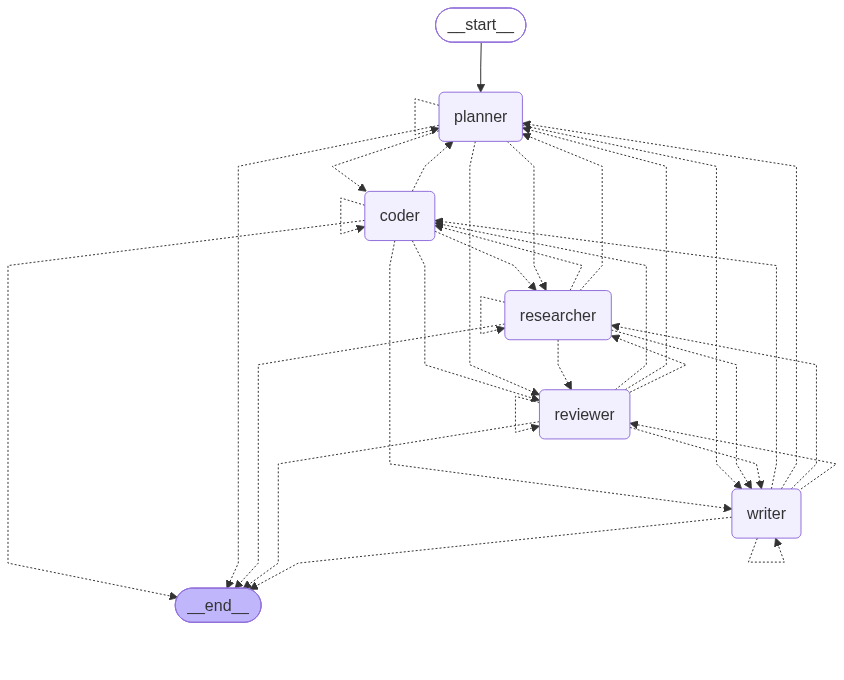

In [72]:
graph

In [74]:

test = graph.invoke({"messages":[HumanMessage(content="can you provide me the code and logic for how i can check if a string is palindrome or not. write it in python and also explain to me.")]})
test


{'messages': [HumanMessage(content='can you provide me the code and logic for how i can check if a string is palindrome or not. write it in python and also explain to me.', additional_kwargs={}, response_metadata={}, id='1cffb83e-c910-4e48-a1a8-833035d9932b'),
  AIMessage(content='Passing to the researcher agent', additional_kwargs={}, response_metadata={}, id='1a5881a1-3597-47bb-b0d2-aa009e24b361', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Research done, key findings on can you provide me the code and logic for how i can check if a string is palindrome or not. write it in python and also explain to me. is : **Task understanding**  \nThe user wants a clear, concise explanation of how to determine whether a given string is a palindrome in Python, along with the actual code that implements this logic.\n\n---\n\n### Key findings\n\n| Topic | Summary |\n|-------|---------|\n| **Definition** | A palindrome reads the same forwards and backwards (ignoring case, whitespace, a

In [75]:
for m in test['messages']:
    m.pretty_print()

================================ Human Message =================================

can you provide me the code and logic for how i can check if a string is palindrome or not. write it in python and also explain to me.
================================== Ai Message ==================================

Passing to the researcher agent
================================== Ai Message ==================================

Research done, key findings on can you provide me the code and logic for how i can check if a string is palindrome or not. write it in python and also explain to me. is : **Task understanding**  
The user wants a clear, concise explanation of how to determine whether a given string is a palindrome in Python, along with the actual code that implements this logic.

---

### Key findings

| Topic | Summary |
|-------|---------|
| **Definition** | A palindrome reads the same forwards and backwards (ignoring case, whitespace, and punctuation if desired). |
| **Typical algorithm** | Rev